In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('C:/Users/SwatiRP/Desktop/sales-forecasting/archive (1)/train.csv')

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Sort values
df = df.sort_values(by='Date')

# Basic check
print(df.head())
print(df.info())

C:\Users\SwatiRP\AppData\Local\Temp\ipykernel_21848\2585431731.py:5: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/Users/SwatiRP/Desktop/sales-forecasting/archive (1)/train.csv')


         Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
1017208   1115          2 2013-01-01      0          0     0      0   
1016473    379          2 2013-01-01      0          0     0      0   
1016472    378          2 2013-01-01      0          0     0      0   
1016471    377          2 2013-01-01      0          0     0      0   
1016470    376          2 2013-01-01      0          0     0      0   

        StateHoliday  SchoolHoliday  
1017208            a              1  
1016473            a              1  
1016472            a              1  
1016471            a              1  
1016470            a              1  
<class 'pandas.DataFrame'>
Index: 1017209 entries, 1017208 to 0
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null 

In [2]:
df = df[df["Open"] == 1]

In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
1016447,353,2,2013-01-01,3139,820,1,0,a,1
1016429,335,2,2013-01-01,2401,482,1,0,a,1
1016606,512,2,2013-01-01,2646,625,1,0,a,1
1016588,494,2,2013-01-01,3113,527,1,0,a,1
1016624,530,2,2013-01-01,2907,532,1,0,a,1


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

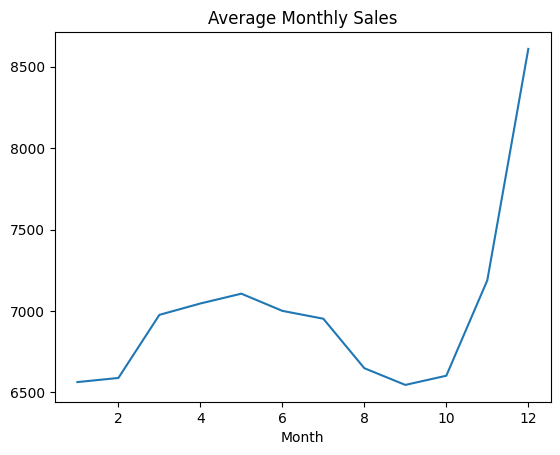

In [5]:
import matplotlib.pyplot as plt

df.groupby("Month")["Sales"].mean().plot()
plt.title("Average Monthly Sales")
plt.show()

In [6]:
df.groupby("Promo")["Sales"].mean()

Promo
0    5929.407603
1    8228.281239
Name: Sales, dtype: float64

In [7]:
df.groupby("DayOfWeek")["Sales"].mean()

DayOfWeek
1    8216.073074
2    7088.113656
3    6728.122978
4    6767.310159
5    7072.677012
6    5874.840238
7    8224.723908
Name: Sales, dtype: float64

In [8]:
df = df.drop(["Date"], axis=1)

In [9]:
df["StateHoliday"] = df["StateHoliday"].astype("category").cat.codes

In [10]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
df_sample = df.sample(50000, random_state=42)

In [13]:
X = df_sample.drop("Sales", axis=1)
y = df_sample["Sales"]

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [16]:
model = RandomForestRegressor(n_estimators=20, random_state=42)

In [18]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",20
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [19]:
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 588.3552558340587


In [21]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))

LR MAE: 1144.7220012073278


In [22]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.4 MB/s eta 0:00:30
    --------------------------------------- 1.8/101.7 MB 3.6 MB/s eta 0:00:28
   - -------------------------------------- 2.6/101.7 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 3.4/101.7 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 4.2/101.7 MB 3.8 MB/s eta 0:00:26
   - -------------------------------------- 5.0/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.0/101.7 MB 3.9 MB/s eta 0:00:25
   -- ------------------------------------- 7.1/101.7 MB 4.0 MB/s eta 0:00:24
   -- ------------------------------------- 7.6/101.7 MB 4.0 MB/s eta 0:00:24
   --- ------------------------------------ 8.4/101.7 MB 3.9 MB/s eta 0:00:24
   --- ------------------------------------ 9.4/101.7 MB 3.9 MB/s eta 0:00:24



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGB MAE:", mean_absolute_error(y_test, y_pred_xgb))

XGB MAE: 782.1578979492188


In [30]:
import sys
sys.path.append("..")

import importlib
import src.insights

importlib.reload(src.insights)

<module 'src.insights' from 'C:\\Users\\SwatiRP\\Desktop\\sales-forecasting\\notebooks\\..\\src\\insights.py'>

In [31]:
from src.insights import generate_insights

In [32]:
insights = generate_insights(df)

for i in insights:
    print(i)

📈 Promotions increase sales
📅 Best day: 7


In [35]:
import joblib

joblib.dump(xgb, "model.pkl")

['model.pkl']

In [36]:
import os
print(os.getcwd())

C:\Users\SwatiRP\Desktop\sales-forecasting\notebooks


In [44]:
import joblib
import pandas as pd

model = joblib.load("model.pkl")

def predict_sales(input_data):
    df = pd.DataFrame([input_data])
    prediction = model.predict(df)[0]
    return int(prediction)

In [47]:
import importlib
import src.predict
importlib.reload(src.predict)

<module 'src.predict' from 'C:\\Users\\SwatiRP\\Desktop\\sales-forecasting\\notebooks\\..\\src\\predict.py'>

In [49]:
from src.insights import generate_insights
from src.predict import predict_sales

# Example input (you can modify)
sample = X.iloc[0].to_dict()

predicted = predict_sales(sample)

print("Predicted Sales:", predicted)

insights = generate_insights(df)

for i in insights:
    print(i)

Predicted Sales: 7356
📈 Promotions increase sales
📅 Best day: 7


In [50]:
import joblib

joblib.dump(xgb, "../models/model.pkl")

['../models/model.pkl']